In [1]:
%matplotlib inline

**Datasets**

- Dataset para modos de articulación: git clone https://github.com/JaredEspinosa19/Dataset_TT 
- Dataset con vocales y consonantes: git clone https://github.com/JaredEspinosa19/Dataset_original 

In [2]:
# Importamos las librerías necesarias

import os                   # Para manejar operaciones del sistema de archivos
import cv2                  # OpenCV para procesamiento de imágenes
import numpy as np           # Numpy para manejo de arrays y operaciones numéricas
import random                # Para la generación de números aleatorios
import tensorflow as tf      # TensorFlow para construir y entrenar modelos de Deep Learning
import matplotlib.pyplot as plt  # Para visualización de datos y gráficos
from tensorflow.keras.models import Sequential, save_model  # Para la construcción y guardado de modelos
from tensorflow.keras.layers import (Conv3D, Conv2D, Flatten, Dense, MaxPooling3D, MaxPooling2D, TimeDistributed, LSTM, Dropout, BatchNormalization)  # Capas utilizadas en el modelo
from tensorflow.keras.utils import Sequence, plot_model  # Utilidades para modelos y generación de secuencias de datos
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Callbacks para mejorar el entrenamiento
from tensorflow.keras.preprocessing.image import (img_to_array, load_img, smart_resize, ImageDataGenerator)  # Preprocesamiento de imágenes
from tensorflow.keras.optimizers import Adam     # Optimizador Adam para ajustar los pesos del modelo
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento y prueba
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score)  # Métricas para evaluar el modelo
from sklearn.utils import shuffle as sk_shuffle
from collections import Counter
import seaborn as sns  # Librería para visualización avanzada de datos
import imageio

# Comprobamos si hay GPUs disponibles para utilizar con TensorFlow
print("Num GPUs disponibles: ", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow utilizará GPU")  # Si hay GPU, se utiliza
else:
    print("TensorFlow utilizará CPU")  # Si no hay GPU, se utiliza CPU


# Variables globales
batch_size = 65     # Tamaño del batch
n_frames_per_sample = 18  # Número de frames por muestra, ya que cada video se ha dividido en 18 imágenes
frame_height = 128   # Altura de cada frame (en píxeles)
frame_width = 128    # Ancho de cada frame (en píxeles)
n_filters = 32       # Número de filtros para las capas convolucionales
epochs = 100          # Número de épocas para el entrenamiento del modelo
n_channels = 3       # Número de canales en las imágenes (3 para RGB)
# learning_rate = 0.001  # Tasa de aprendizaje para el optimizador Adam

# Alternativa comentada para la tasa de aprendizaje más baja:
learning_rate = 0.0001

dataset_path = '/teamspace/studios/this_studio/Dataset_TT/Modo Sinfones'                                                        # Ruta del dataset que se utilizará
trained_model_path = f'/teamspace/studios/this_studio/Modelos entrenados/CNN_3D_sinfones_{epochs}epochs_{batch_size}batch_size.keras'            # Ruta para guardar o cargar el modelo entrenado
output_dir = '/teamspace/studios/this_studio/Modelos entrenados'                                                                        # Ruta para guardar las gráficas de precisión, perdida, matriz e informe de clasificación
checkpoint_path = '/teamspace/studios/this_studio/Modelos entrenados/Mejores_pesos.h5'      # Ruta para guardar el archivo con los mejores pesos

2024-10-30 20:12:40.427633: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-30 20:12:40.427857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-30 20:12:40.456194: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-30 20:12:40.529751: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 20:12:41.491773: W tensorflow/compiler/tf2

Num GPUs disponibles:  1
TensorFlow utilizará GPU


# Generador y funciones

In [3]:
## GENERADOR ##
class CustomDataGenerator(Sequence):
    def __init__(self, root_dir, mode='train', batch_size=32, frames_per_sample=18, target_size=(128, 128), n_channels=3, shuffle=False):
        """
        Inicializa el generador para una modalidad específica (train, validation o test).

        Parámetros:
        - root_dir: Ruta de la carpeta raíz que contiene los datos organizados por clasificación.
        - mode: Modalidad del generador ('train', 'validation', 'test').
        - batch_size: Tamaño del lote.
        - frames_per_sample: Número de frames por muestra.
        - target_size: Dimensiones de las imágenes (ancho y alto).
        - n_channels: Número de canales de color (3 para RGB).
        - shuffle: Indica si los datos deben mezclarse o no.
        """
        self.root_dir = root_dir  # Se pasa directamente la ruta de la clasificación
        self.mode = mode
        self.batch_size = batch_size
        self.frames_per_sample = frames_per_sample
        self.target_size = target_size
        self.n_channels = n_channels
        self.shuffle = shuffle  # Establece si los datos deben mezclarse o no

        # Las clases ahora son las subcarpetas dentro del directorio raíz que representa la clasificación
        self.classes = sorted(os.listdir(self.root_dir))
        self.class_to_index = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.dataset_info = self.prepare_dataset()
        self.samples = self.dataset_info[mode]

        # Si shuffle es True, mezcla las muestras al inicializar el generador
        if self.shuffle:
            self.samples = sk_shuffle(self.samples)

    def __len__(self):
        """
        Define la cantidad de lotes por época.
        """
        return len(self.samples) // self.batch_size

    def prepare_dataset(self):
        """
        Prepara el dataset dividiendo las muestras en train, validation y test.
        Asegura que cada subcarpeta tiene exactamente 68 muestras (o más, ajustable según el dataset).

        Retorna:
        - Diccionario con las muestras divididas en 'train', 'validation' y 'test'.
        """
        random.seed(42)  # Fija la semilla para asegurar consistencia en la división de datos
        all_files = {letter: [] for letter in self.classes}

        # Recorre cada subcarpeta (clase: Alveolar, Bilabial, Dental, etc.)
        for letter_dir in self.classes:
            letter_path = os.path.join(self.root_dir, letter_dir)
            
            for syllable_dir in os.listdir(letter_path):  # Subcarpetas de cada clase, como L, N, etc.
                syllable_path = os.path.join(letter_path, syllable_dir)

                for subsyllable_dir in os.listdir(syllable_path):  # Subcarpetas como LA, LE, LI, etc.
                    subsyllable_path = os.path.join(syllable_path, subsyllable_dir)
                    sample_paths = [os.path.join(subsyllable_path, sample_dir) for sample_dir in os.listdir(subsyllable_path)]
                    random.shuffle(sample_paths)  # Mezcla las muestras de forma aleatoria

                    # Asegurarse de que haya suficientes carpetas para train, val, y test
                    if len(sample_paths) >= 68:  # Asegurando que hay al menos 68 muestras
                        # Divide las muestras en train, val, y test
                        train_samples = sample_paths[:50]
                        val_samples = sample_paths[50:59]
                        test_samples = sample_paths[59:68]

                        for sample_dir in train_samples:
                            frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                            if len(frame_files) == self.frames_per_sample:
                                all_files[letter_dir].append(('train', frame_files))  # Marcar como 'train'

                        for sample_dir in val_samples:
                            frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                            if len(frame_files) == self.frames_per_sample:
                                all_files[letter_dir].append(('validation', frame_files))  # Marcar como 'validation'

                        for sample_dir in test_samples:
                            frame_files = [os.path.join(sample_dir, f) for f in sorted(os.listdir(sample_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                            if len(frame_files) == self.frames_per_sample:
                                all_files[letter_dir].append(('test', frame_files))  # Marcar como 'test'

        # Organiza las muestras
        train, val, test = [], [], []
        for letter, samples in all_files.items():
            for sample in samples:
                mode, frame_files = sample
                if mode == 'train':
                    train.append((letter, frame_files))
                elif mode == 'validation':
                    val.append((letter, frame_files))
                elif mode == 'test':
                    test.append((letter, frame_files))

        return {'train': train, 'validation': val, 'test': test}

    def __getitem__(self, index):
        """
        Genera lotes de datos.

        Parámetros:
        - index: Índice del lote a generar.

        Retorna:
        - X_batch: Lote de imágenes.
        - y_batch: Lote de etiquetas (one-hot encoding).
        """
        batch_samples = self.samples[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = np.zeros((self.batch_size, self.frames_per_sample, *self.target_size, self.n_channels))
        y_batch = np.zeros((self.batch_size, len(self.classes)))

        # Procesa cada muestra del lote
        for i, (class_label, frames) in enumerate(batch_samples):
            class_index = self.class_to_index[class_label]

            # Carga los frames de la muestra
            images = [img_to_array(load_img(frame, color_mode='rgb', target_size=self.target_size)) / 255.0 for frame in frames]
            frames_array = np.array(images)

            X_batch[i] = frames_array
            y_batch[i, class_index] = 1   # Etiqueta one-hot

        return X_batch, y_batch

    def on_epoch_end(self):
        """
        Si shuffle está activado, mezcla las muestras al final de cada época.
        """
        if self.shuffle:
            self.samples = sk_shuffle(self.samples)




## ---------------------------------------------------------------------------------------------------------------------------- ##
## ---------------------------------------------------------------------------------------------------------------------------- ##

## FUNCIONES EXTRA (OPCIONALES) ##
#Funciones para observar los datos dentro de los generadores.

# Función para imprimir las muestras de cada partición (train, validation, test):
def print_sample_directories(generator):
    # Imprime las muestras de entrenamiento (train)
    print("Muestras en TRAIN:")
    for letter, frames in generator.dataset_info['train']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")
    
    # Imprime las muestras de validación (validation)
    print("\nMuestras en VALIDATION:")
    for letter, frames in generator.dataset_info['validation']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")
    
    # Imprime las muestras de prueba (test)
    print("\nMuestras en TEST:")
    for letter, frames in generator.dataset_info['test']:
        print(f"Clase: {letter}, Directorio de muestra: {os.path.dirname(frames[0])}")



# Esta función cuenta cuántas muestras hay en cada una de las particiones del dataset
def count_samples_per_division(generator):
    # Cuenta las muestras en el conjunto de entrenamiento (train)
    train_samples = len(generator.dataset_info['train'])
    
    # Cuenta las muestras en el conjunto de validación (validation)
    validation_samples = len(generator.dataset_info['validation'])
    
    # Cuenta las muestras en el conjunto de prueba (test)
    test_samples = len(generator.dataset_info['test'])
    
    # Imprime el total de muestras en cada partición
    print("\n\n")
    print(f"Total de muestras en TRAIN: {train_samples}")
    print(f"Total de muestras en VALIDATION: {validation_samples}")
    print(f"Total de muestras en TEST: {test_samples}")



# Esta función toma un batch de secuencias generadas por el generador y las visualiza.
# Por defecto, visualiza 4 secuencias, pero se puede ajustar el número de secuencias a mostrar.
def visualize_generated_sequences(generator, num_sequences=4):
    # Obtiene el primer batch del generador
    X_batch, y_batch = generator.__getitem__(0)
    
    # Asegura que no se intenten visualizar más secuencias de las que hay en el batch
    num_sequences = min(num_sequences, X_batch.shape[0])

    # Visualiza las secuencias
    for i in range(num_sequences):
        plt.figure(figsize=(15, 3))  # Ajusta el tamaño de la figura
        for j in range(generator.frames_per_sample):  # Recorre los frames de cada secuencia
            plt.subplot(1, generator.frames_per_sample, j + 1)  # Crea subplots para cada frame
            if generator.n_channels == 1:
                # Si las imágenes están en escala de grises
                plt.imshow(X_batch[i, j, :, :, 0], cmap='gray')
            else:
                # Si las imágenes están en formato RGB
                plt.imshow(X_batch[i, j, :, :, :])
            plt.axis('off')  # Oculta los ejes
        plt.show()  # Muestra las imágenes



# Código para verificar las muestras entregadas por los generadores
def contar_muestras_generador(generator):
    contador = Counter()
    for i in range(len(generator)):
        _, y_batch = generator[i]
        etiquetas = np.argmax(y_batch, axis=1)  # Obtener los índices de las clases
        for etiqueta in etiquetas:
            contador[etiqueta] += 1
    return contador

def print_sample_count(test_generator, sample_count):
    # Mapear índices a nombres de clases
    indice_a_clase = {v: k for k, v in test_generator.class_to_index.items()}

    # Imprimir el conteo de muestras por clase
    for idx, count in sample_count.items():
        print(f"Clase: {indice_a_clase[idx]}, Muestras: {count}")




## ---------------------------------------------------------------------------------------------------------------------------- ##
## ---------------------------------------------------------------------------------------------------------------------------- ##

# FUNCIÓN PARA IMPRIMIR Y GUARDAR LAS GRÁFICAS DE PRECISIÓN Y PÉRDIDA
def print_accuracy_loss(history, output_dir):
    # Sumarizar la historia de la precisión
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Precisión del modelo')
    plt.ylabel('Precisión')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.savefig(f'{output_dir}/precision.png')  # Guardar la gráfica de precisión
    plt.show()
    
    # Sumarizar la historia de la pérdida
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Pérdida del modelo')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.savefig(f'{output_dir}/perdida.png')  # Guardar la gráfica de pérdida
    plt.show()

# FUNCIÓN PARA IMPRIMIR Y GUARDAR LA MATRIZ DE CONFUSIÓN Y EL REPORTE DE CLASIFICACIÓN
def print_conf_matriz_classif_report(model, test_generator, output_dir):
    # Matriz de confusión e Informe de clasificación
    y_true = []
    y_pred = []

    # Recorremos el conjunto de datos de test para obtener las etiquetas reales y las predicciones
    for i in range(len(test_generator)):
        X_test, y_test = test_generator.__getitem__(i)
        preds = model.predict(X_test)

        y_true.extend(np.argmax(y_test, axis=1))  # Etiquetas reales
        y_pred.extend(np.argmax(preds, axis=1))   # Predicciones

    # Matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Graficar la matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_to_index.keys(), yticklabels=test_generator.class_to_index.keys())
    plt.xlabel('Predicciones')
    plt.ylabel('Etiquetas verdaderas')
    plt.title('Matriz de Confusión')
    plt.savefig(f'{output_dir}/matriz_confusion.png')  # Guardar la gráfica de matriz de confusión
    plt.show()

    # Informe de clasificación
    class_report = classification_report(y_true, y_pred, target_names=test_generator.class_to_index.keys())
    
    # Guardar el informe en un archivo de texto
    with open(f'{output_dir}/informe_clasificacion.txt', 'w') as f:
        f.write(class_report)

    # Imprimir el informe en consola también
    print(class_report)


# Generadores (train, validation, test)

In [4]:
# Crear generadores para train, validation y test con la opción de shuffle
train_generator = CustomDataGenerator(dataset_path, mode='train', batch_size=batch_size, shuffle=True)
validation_generator = CustomDataGenerator(dataset_path, mode='validation', batch_size=batch_size, shuffle=False)
test_generator = CustomDataGenerator(dataset_path, mode='test', batch_size=batch_size, shuffle=False)

#### Funciones extra (opcionales)

Funciones para observar los datos dentro de los generadores. No es necesario ejecutar esta parte.

In [5]:
# print_sample_directories(train_generator)
# count_samples_per_division(train_generator)
# visualize_generated_sequences(train_generator, num_sequences=5)


# conteo_muestras = contar_muestras_generador(test_generator)
# print_sample_count(test_generator, conteo_muestras)

# Modelo CNN 3D

In [6]:
# Optimizador con el learning rate especificado
optimizer = Adam(learning_rate=learning_rate)

# Definición del modelo
model = Sequential()

# Ajuste de las dimensiones de entrada
input_shape = (n_frames_per_sample, frame_height, frame_width, n_channels)  # Sin el batch_size

# Capas 3D Conv
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), input_shape=input_shape, activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))
model.add(Conv3D(n_filters, kernel_size=(3, 3, 3), activation='relu'))
model.add(MaxPooling3D(pool_size=(1, 2, 2)))

# Capas Flatten
model.add(Flatten())

# Capas totalmente conectadas
model.add(Dense(500, activation='relu'))
model.add(Dense(500, activation='relu'))

# Número de clases (ajustar según el número de clases en tu dataset)
n_classes = len(train_generator.class_to_index)  # Ajusta este valor si es diferente
model.add(Dense(n_classes, activation='softmax'))  # Salida

# Compilación del modelo
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.summary()

# Dibujo del modelo
# plot_model(model, 'CNN 3D.png', show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 16, 126, 126, 32   2624      
                             )                                   
                                                                 
 max_pooling3d (MaxPooling3  (None, 16, 63, 63, 32)    0         
 D)                                                              
                                                                 
 conv3d_1 (Conv3D)           (None, 14, 61, 61, 32)    27680     
                                                                 
 max_pooling3d_1 (MaxPoolin  (None, 14, 30, 30, 32)    0         
 g3D)                                                            
                                                                 
 conv3d_2 (Conv3D)           (None, 12, 28, 28, 32)    27680     
                                                        

2024-10-30 20:12:47.156059: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20974 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,         # Ruta para guardar los pesos
    monitor='val_loss',               # Métrica a monitorear
    verbose=1,                        # Información en pantalla
    save_best_only=True,              # Guardar solo los mejores pesos
    mode='min'                        # 'min' para val_loss (guardar pesos cuando val_loss disminuye)
)

# Entrenamiento del modelo
history = model.fit(
    train_generator,  # Pasa el generador directamente para entrenamiento
    validation_data=validation_generator,  # Usa el generador para validación
    epochs=epochs,  # Número de épocas
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[checkpoint, early_stopping]
)

# history = model.fit(
#     train_generator,  # Pasa el generador directamente para entrenamiento
#     validation_data=validation_generator,  # Usa el generador para validación
#     epochs=epochs,  # Número de épocas
#     steps_per_epoch=len(train_generator),
#     validation_steps=len(validation_generator)
# )

Epoch 1/100


2024-10-30 20:14:20.563193: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2024-10-30 20:14:29.081393: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ff76d446df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-30 20:14:29.081425: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2024-10-30 20:14:29.103533: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1730319269.313728    4279 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 [==============================] - ETA: 0s - loss: 1.3519 - accuracy: 0.3111 
Epoch 1: val_loss improved from inf to 1.33086, saving model to /teamspace/studios/this_studio/Modelos entrenados/Mejores_pesos.h5
50/50 [==============================] - 963s 18s/step - loss: 1.3519 - accuracy: 0.3111 - val_loss: 1.3309 - val_accuracy: 0.4154
Epoch 2/100


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


50/50 [==============================] - ETA: 0s - loss: 1.3118 - accuracy: 0.3822
Epoch 2: val_loss improved from 1.33086 to 1.26625, saving model to /teamspace/studios/this_studio/Modelos entrenados/Mejores_pesos.h5
50/50 [==============================] - 70s 1s/step - loss: 1.3118 - accuracy: 0.3822 - val_loss: 1.2662 - val_accuracy: 0.4205
Epoch 3/100
50/50 [==============================] - ETA: 0s - loss: 1.2429 - accuracy: 0.4378
Epoch 3: val_loss improved from 1.26625 to 1.19968, saving model to /teamspace/studios/this_studio/Modelos entrenados/Mejores_pesos.h5
50/50 [==============================] - 51s 1s/step - loss: 1.2429 - accuracy: 0.4378 - val_loss: 1.1997 - val_accuracy: 0.4496
Epoch 4/100
50/50 [==============================] - ETA: 0s - loss: 1.1369 - accuracy: 0.5031
Epoch 4: val_loss improved from 1.19968 to 1.14921, saving model to /teamspace/studios/this_studio/Modelos entrenados/Mejores_pesos.h5
50/50 [==============================] - 62s 1s/step - loss: 1.1

In [8]:
# fGuarda el modelo entrenado
model.save(trained_model_path)

#### ***accuracy***, ***loss***, ***confusion_matrix*** y ***classification_report***

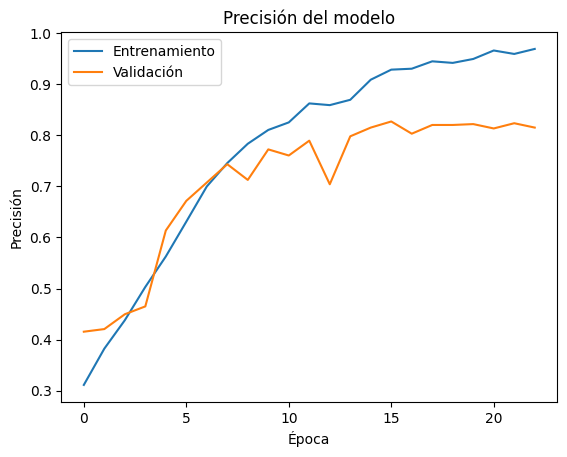

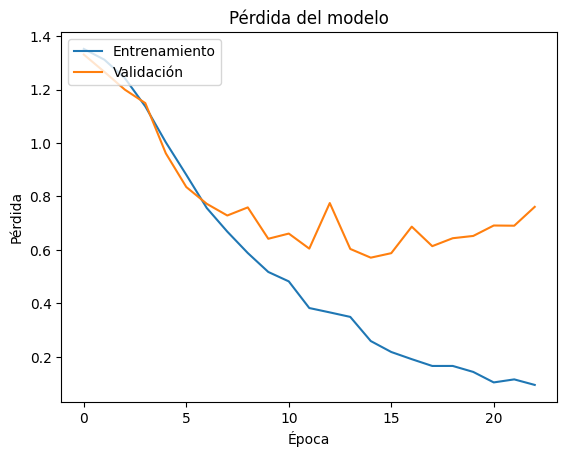

3/3 [==============================] - 0s 64ms/step


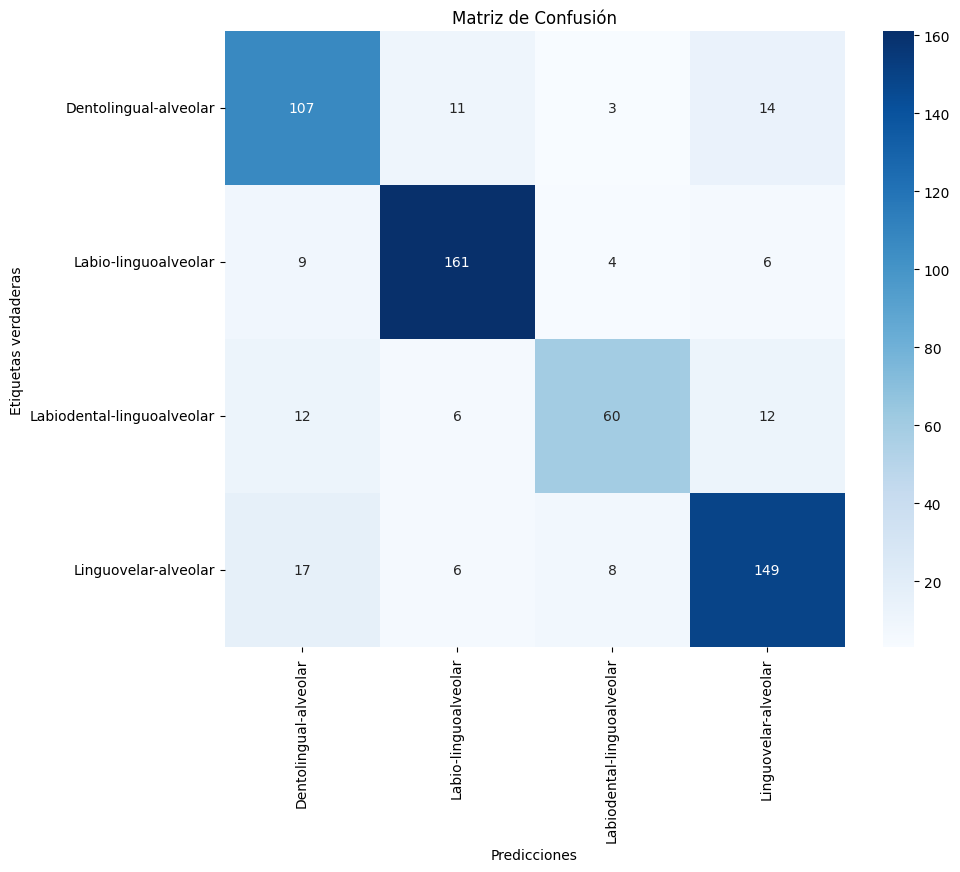

                            precision    recall  f1-score   support

     Dentolingual-alveolar       0.74      0.79      0.76       135
      Labio-linguoalveolar       0.88      0.89      0.88       180
Labiodental-linguoalveolar       0.80      0.67      0.73        90
      Linguovelar-alveolar       0.82      0.83      0.83       180

                  accuracy                           0.82       585
                 macro avg       0.81      0.80      0.80       585
              weighted avg       0.82      0.82      0.81       585



In [9]:
print_accuracy_loss(history=history, output_dir=output_dir)
print_conf_matriz_classif_report(model=model, test_generator=test_generator, output_dir=output_dir)

# Funciones para cargar un modelo previamente entrenado y obtener ***confusion_matrix*** y ***classification_report***

In [48]:
# Función para cargar un modelo previamente entrenado
def load_trained_model(model_path):
    model = tf.keras.models.load_model(model_path)
    return model

trained_model_path = '/teamspace/studios/this_studio/modo_100ep_85bz_0001lr/CNN_3D_modo_100epochs_85batch_size.keras'
# Cargar el modelo previamente entrenado
model = load_trained_model(trained_model_path)

In [ ]:
print_conf_matriz_classif_report(model=model, test_generator=test_generator, output_dir=output_dir)

# Grad-CAM

In [81]:
def get_gradcam_heatmap_3d(model, img_array, layer_name):
    """
    Función para generar un heatmap utilizando Grad-CAM en un modelo 3D CNN.
    
    Parámetros:
    - model: Modelo 3D CNN entrenado.
    - img_array: Arreglo de numpy con la muestra de entrada (1 muestra, 18 frames de tamaño 128x128).
    - layer_name: Nombre de la última capa convolucional 3D del modelo.
    """
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # Ejecuta el gradiente para obtener la pérdida de la clase predicha respecto a las activaciones
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, tf.argmax(predictions[0])]

    # Calcula los gradientes de la pérdida con respecto a las activaciones
    grads = tape.gradient(loss, conv_outputs)
    
    # Toma el valor promedio de los gradientes a lo largo de los frames y ejes espaciales
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # Multiplica cada canal en el mapa de activación por el gradiente promedio
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Aplicar ReLU para obtener solo valores positivos
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam_sequence_adjusted(img_array, heatmap, class_label, alpha=0.4):
    """
    Muestra el heatmap Grad-CAM sobre una cantidad ajustada de frames de la secuencia completa,
    según la cantidad de frames en la capa convolucional de salida.
    
    Parámetros:
    - img_array: Arreglo de numpy con la secuencia de frames de entrada.
    - heatmap: Heatmap generado por Grad-CAM, ajustado para coincidir con el tamaño de la capa convolucional.
    - alpha: Nivel de transparencia del heatmap.
    """
    n_frames_heatmap = heatmap.shape[0]  # Número de frames en el heatmap (capa convolucional)
    total_frames = img_array.shape[1]    # Total de frames en la secuencia de entrada

    # Verificar que `img_array` tiene suficientes frames; si no, ajustar
    step = total_frames // n_frames_heatmap  # Paso para ajustar el tamaño de la secuencia

    # Itera sobre cada frame en el heatmap y elige frames correspondientes de `img_array`
    for frame_index in range(n_frames_heatmap):
        # Calcula el índice del frame correspondiente en `img_array`
        img = img_array[0, frame_index * step]  # Ajusta los frames de `img_array` al tamaño del heatmap
        heatmap_frame = heatmap[frame_index]    # Heatmap correspondiente al frame

        # Redimensiona el heatmap para que coincida con la imagen original
        heatmap_resized = np.uint8(255 * heatmap_frame)
        heatmap_resized = tf.image.resize(heatmap_resized[..., np.newaxis], (img.shape[0], img.shape[1]))
        heatmap_resized = np.squeeze(heatmap_resized)

        # Muestra el frame con el heatmap superpuesto
        plt.figure(figsize=(4, 4))  # Tamaño de cada figura individual
        plt.imshow(img)
        plt.imshow(heatmap_resized, cmap='jet', alpha=alpha)  # Superpone el heatmap con transparencia
        plt.axis('off')
        # plt.title(f'Frame {frame_index + 1}')
        plt.title(f'Class: {class_label} - Frame {frame_index + 1}', fontsize=12)  # Agrega la clase y el número de frame
        
        plt.show()
        

def save_gradcam_sequence_as_gif(img_array, heatmap, class_label, gif_path, alpha=0.4):
    """
    Guarda el Grad-CAM aplicado a la secuencia completa como un GIF animado con la etiqueta de la clase.
    
    Parámetros:
    - img_array: Arreglo de numpy con la secuencia de frames de entrada.
    - heatmap: Heatmap generado por Grad-CAM, ajustado para coincidir con el tamaño de la capa convolucional.
    - class_label: Etiqueta de la clase de la muestra.
    - alpha: Nivel de transparencia del heatmap.
    - gif_path: Ruta donde se guardará el archivo GIF.
    """
    n_frames_heatmap = heatmap.shape[0]  # Número de frames en el heatmap (capa convolucional)
    total_frames = img_array.shape[1]    # Total de frames en la secuencia de entrada
    step = total_frames // n_frames_heatmap  # Paso para ajustar el tamaño de la secuencia
    
    images = []  # Lista para almacenar cada frame como imagen

    # Itera sobre cada frame en el heatmap y elige frames correspondientes de `img_array`
    for frame_index in range(n_frames_heatmap):
        # Calcula el índice del frame correspondiente en `img_array`
        img = img_array[0, frame_index * step]  # Ajusta los frames de `img_array` al tamaño del heatmap
        heatmap_frame = heatmap[frame_index]    # Heatmap correspondiente al frame

        # Redimensiona el heatmap para que coincida con la imagen original
        heatmap_resized = np.uint8(255 * heatmap_frame)
        heatmap_resized = tf.image.resize(heatmap_resized[..., np.newaxis], (img.shape[0], img.shape[1]))
        heatmap_resized = np.squeeze(heatmap_resized)

        # Superpone el heatmap sobre la imagen
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.imshow(heatmap_resized, cmap='jet', alpha=alpha)  # Superpone el heatmap con transparencia
        plt.axis('off')
        plt.title(f'Class: {class_label}', fontsize=12)  # Agrega la clase y el número de frame

        # Guarda la imagen temporalmente
        image_path = f'temp_frame_{frame_index}.png'
        plt.savefig(image_path)
        plt.close()

        # Cargar la imagen guardada y agregarla a la lista
        images.append(imageio.imread(image_path))

    # Crear el GIF a partir de las imágenes
    imageio.mimsave(gif_path, images, duration=0.8)  # Duración de 0.5 segundos entre frames

    # Limpiar las imágenes temporales
    for image_path in [f'temp_frame_{i}.png' for i in range(n_frames_heatmap)]:
        os.remove(image_path)

    print(f'GIF guardado en {gif_path}')

In [78]:
n = 17
x1 = n+0
x2 = n+1
# Obtén una muestra de datos desde el generador de test (o cualquier otro)
X_batch, y_batch = test_generator[2]  # Primer lote del generador de test
img_array = X_batch[x1:x2]  # Selecciona la primera muestra del lote
class_label = test_generator.classes[np.argmax(y_batch[0])]  # Obtiene la etiqueta de clase

# Elige la capa convolucional 3D a analizar (ajusta el nombre según tu modelo)
layer_name = 'conv3d_3'  # Ajusta el nombre de la capa según el resumen de tu modelo
heatmap = get_gradcam_heatmap_3d(model, img_array, layer_name)


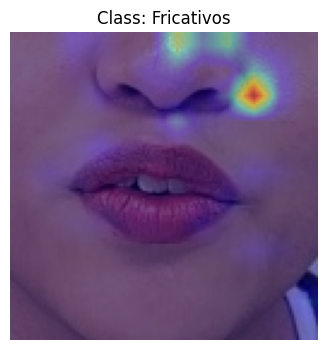

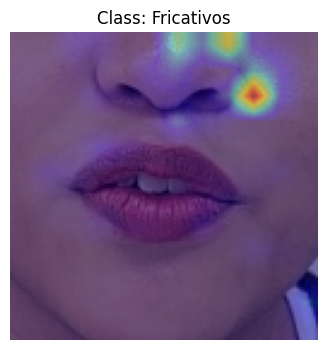

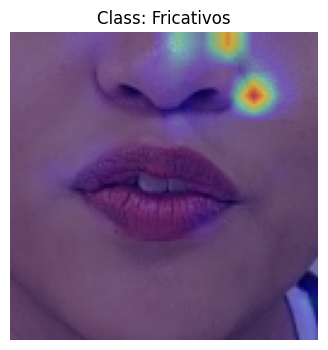

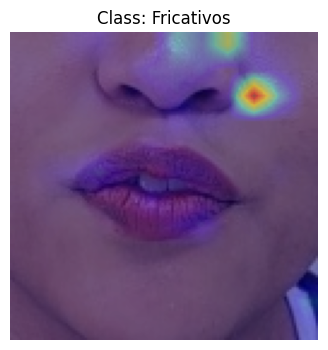

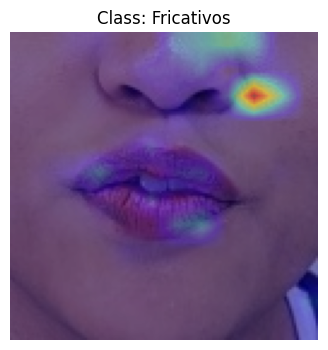

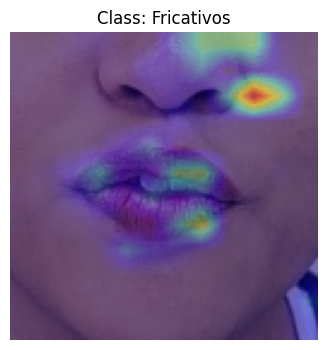

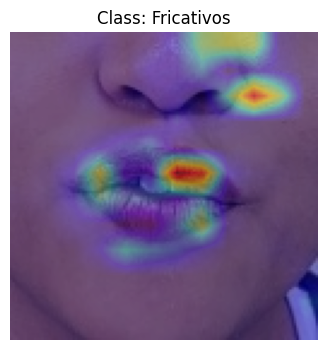

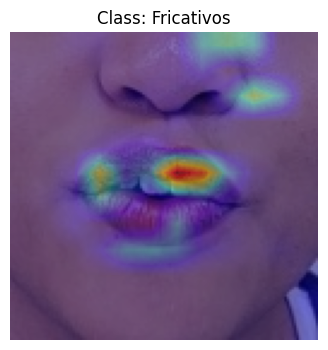

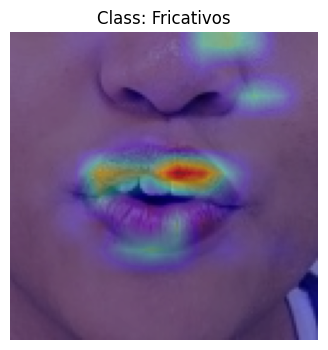

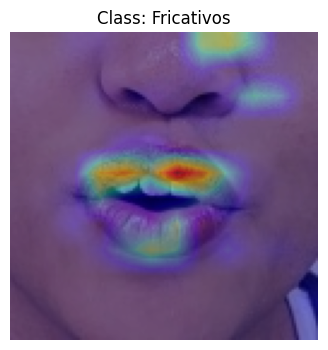

In [82]:
# Visualiza la secuencia ajustada con el Grad-CAM
display_gradcam_sequence_adjusted(img_array, heatmap, class_label=class_label)


In [83]:
gif_path = f'/teamspace/studios/this_studio/modo_100ep_85bz_0001lr/gradcam_sequence_vocal_{class_label}.gif'

# Llamar a la función para generar el GIF, pasando la etiqueta de la clase
save_gradcam_sequence_as_gif(img_array, heatmap, class_label=class_label, gif_path=gif_path)

/tmp/ipykernel_1438/67725516.py:114: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(image_path))


GIF guardado en /teamspace/studios/this_studio/modo_100ep_85bz_0001lr/gradcam_sequence_vocal_Fricativos.gif
